In [1]:
try:
    import xgboost, lightgbm as lgb
except:
    %pip install -q lightgbm xgboost==3.1.0 
    import xgboost, lightgbm as lgb

/usr/local/lib/python3.12/dist-packages/sqlalchemy/orm/query.py:195: SyntaxWarning: "is not" with 'tuple' literal. Did you mean "!="?
  if entities is not ():


In [2]:
!pip show xgboost

Name: xgboost
Version: 3.1.0
Summary: XGBoost Python Package
Home-page: 
Author: 
Author-email: Hyunsu Cho <chohyu01@cs.washington.edu>, Jiaming Yuan <jm.yuan@outlook.com>
License: Apache-2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy, nvidia-nccl-cu12, scipy
Required-by: TPOT


In [3]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device: CPU 4 cores


In [4]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
from itertools import combinations, product

## -- Machine Learning --
import sklearn
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import mean_squared_error, PredictionErrorDisplay

import warnings

warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')
# sklearn.set_config(transform_output="pandas")

In [5]:
# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
plt.style.use("ggplot")
# sns.set_style("whitegrid")
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
PALETTE = ['c', 'r', 'orange']

## -- Set Global Seed --
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

COLOR = '\033[32m'
RESET = '\033[0m'

# from google.colab import data_table
# data_table.enable_dataframe_formatter()

In [6]:
### Load Data ###
PATH = '/kaggle/input/playground-series-s6e1/'
submit = pd.read_csv(PATH+'sample_submission.csv')
train = pd.read_csv(PATH+'train.csv').drop('id', axis=1)
test = pd.read_csv(PATH+'test.csv').drop('id', axis=1)

TARGET = train.columns[-1]
NUMS = test.select_dtypes(include='number').columns.tolist()
CATS = test.select_dtypes(exclude='number').columns.tolist()
BASE = NUMS + CATS

orig = pd.read_csv('/kaggle/input/exam-score-prediction-dataset/Exam_Score_Prediction.csv').drop('student_id', axis=1)

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (630000, 12)
Test shape: (270000, 11)
Original shape: (20000, 12)

Total Numerical: 4
Total Categorical: 7
Total base features: 11


In [7]:
# ## -- Check if id is unique --
# print(f"Train ID column is Unique: {train.id.is_unique}")
# print(f"Test ID column is Unique: {test.id.is_unique}")

In [8]:
display(train.head())
train.info()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   age               630000 non-null  int64  
 1   gender            630000 non-null  object 
 2   course            630000 non-null  object 
 3   study_hours       630000 non-null  float64
 4   class_attendance  630000 non-null  float64
 5   internet_access   630000 non-null  object 
 6   sleep_hours       630000 non-null  float64
 7   sleep_quality     630000 non-null  object 
 8   study_method      630000 non-null  object 
 9   facility_rating   630000 non-null  object 
 10  exam_difficulty   630000 non-null  object 
 11  exam_score        630000 non-null  float64
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ MB


In [9]:
train.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
age,630000.0,20.545821,2.260238,17.000,19.00,21.0,23.00,24.00
study_hours,630000.0,4.002337,2.359880,0.080,1.97,4.0,6.05,7.91
class_attendance,630000.0,71.987261,17.430098,40.600,57.00,72.6,87.20,99.40
sleep_hours,630000.0,7.072758,1.744811,4.100,5.60,7.1,8.60,9.90
exam_score,630000.0,62.506672,18.916884,19.599,48.80,62.6,76.30,100.00


In [10]:
train.describe(exclude='number').T

,count,unique,top,freq
gender,630000,3,other,211097
course,630000,7,b.tech,131236
internet_access,630000,2,yes,579423
sleep_quality,630000,3,poor,213675
study_method,630000,5,coaching,131697
facility_rating,630000,3,medium,214082
exam_difficulty,630000,3,moderate,353982


In [11]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient(cmap='bone')

,age,study_hours,class_attendance,sleep_hours,gender,course,internet_access,sleep_quality,study_method,facility_rating,exam_difficulty
Train,8,792,617,66,3,7,2,3,5,3,3
Original,8,784,589,59,3,7,2,3,5,3,3
Test,8,786,604,64,3,7,2,3,5,3,3


## FEATURE ENGINEERING

### ~ USE PREDICTED FEATURES

In [12]:
## -- Append predicted columns as extra features --
## -- os.walk: Deep search with subfolders --
def dataloader(filepath):    
    train_df = pd.DataFrame()
    test_df = pd.DataFrame()
    
    # print("Loading .npy: ", end="")
    # for (root, dirs, files) in os.walk(filepath):
    #     for i, file in enumerate(sorted(files), 1):
    #         if i%5 == 0: print(f"{i}%.. ", end="")
    #         if file.endswith(".npy") and "train" in file:
    #             train_path = np.load(os.path.join(root, file))
    #             train = pd.concat([train, pd.Series(train_path, name=file[6:-4])], axis=1)
    #         elif file.endswith(".npy") and "test" in file:
    #             test_path = np.load(os.path.join(root, file))
    #             test = pd.concat([test, pd.Series(test_path, name=file[5:-4])], axis=1)
    # print()
    print("Loading .parquet files: ", end="")
    for (root, dirs, files) in os.walk(filepath):
        for i, file in enumerate(sorted(files), 1):
            if i%5 == 0: print(f"{i}%.. ", end="")
            if file.endswith(".parquet") and "train" in file:
                train_path = os.path.join(root, file)
                train_df = pd.concat([train_df, pd.read_parquet(train_path)], axis=1)
            elif file.endswith(".parquet") and "test" in file:
                test_path = os.path.join(root, file)
                test_df = pd.concat([test_df, pd.read_parquet(test_path)], axis=1)
    print()
    print(f"Total train models: {len(train_df.columns)} || Shape: {train_df.shape}")
    print(f"Total test models : {len(test_df.columns)} || Shape: {test_df.shape}")
    print()
    

    return train_df, test_df

In [13]:
PATHS = [
    # '/kaggle/input/ps6e1-per-feature-ag',
    '/kaggle/input/ps6e1-autogluon-trainorig',
    # '/kaggle/input/ps6e1-lr-gbdt-nn-trainorig',
]

## -- Load dataframes --
train_dfs = []
test_dfs  = []

## -- Load train/test datasets --
for p in PATHS:
    tr, ts = dataloader(p)
    train_dfs.append(tr)
    test_dfs.append(ts)

## -- Concat datasets --
ext_train = pd.concat(train_dfs, axis=1)
ext_test  = pd.concat(test_dfs, axis=1)

print('External data loaded', ext_train.shape, ext_test.shape)

## -- Drop weighted autogluon models --
for c in ext_train.columns:
    if 'L2' in c or 'L3' in c: # 
        ext_train.drop([c], axis=1, inplace=True)
        ext_test.drop([c], axis=1, inplace=True)
    elif c == TARGET:
        ext_train.drop([c], axis=1, inplace=True)
    
## -- Check for missing values --
print('Check missingness:', ext_train.isna().sum().sum(), ext_test.isna().sum().sum())

display(ext_train.head(3))
display(ext_test.head(3))

Loading .parquet files: 
Total train models: 64 || Shape: (630000, 64)
Total test models : 64 || Shape: (270000, 64)

External data loaded (630000, 64) (270000, 64)
Check missingness: 0 0


,LightGBMXTBAGL1,LightGBMBAGL1,RandomForestMSEBAGL1,CatBoostBAGL1,ExtraTreesMSEBAGL1,NeuralNetFastAIBAGL1,XGBoostBAGL1,NeuralNetTorchBAGL1,LightGBMLargeBAGL1,CatBoostr177BAGL1,NeuralNetTorchr79BAGL1,LightGBMr131BAGL1,NeuralNetFastAIr191BAGL1,CatBoostr9BAGL1,LightGBMr96BAGL1,NeuralNetTorchr22BAGL1,XGBoostr33BAGL1,ExtraTreesr42BAGL1,CatBoostr137BAGL1,NeuralNetFastAIr102BAGL1,CatBoostr13BAGL1,RandomForestr195BAGL1,LightGBMr188BAGL1,NeuralNetFastAIr145BAGL1,XGBoostr89BAGL1,NeuralNetTorchr30BAGL1,LightGBMr130BAGL1,NeuralNetTorchr86BAGL1,CatBoostr50BAGL1,NeuralNetFastAIr11BAGL1,XGBoostr194BAGL1,ExtraTreesr172BAGL1,CatBoostr69BAGL1,NeuralNetFastAIr103BAGL1,NeuralNetTorchr14BAGL1,LightGBMr161BAGL1,NeuralNetFastAIr143BAGL1,CatBoostr70BAGL1,NeuralNetFastAIr156BAGL1,LightGBMr196BAGL1,RandomForestr39BAGL1,CatBoostr167BAGL1,NeuralNetFastAIr95BAGL1,NeuralNetTorchr41BAGL1
0,85.849228,87.484894,87.250336,85.963348,85.650665,84.673004,88.859543,86.942528,88.528526,86.035973,86.280724,87.229767,86.014473,87.062050,84.768204,86.008369,85.999321,85.688667,85.564217,85.365067,85.918915,86.196999,85.050369,85.806580,85.434624,86.682762,87.138199,86.820404,85.664490,85.297905,87.340195,86.773010,85.848602,85.149376,86.894615,87.987770,87.070053,86.673767,86.080109,85.251068,87.586472,86.010040,85.801155,86.368408
1,66.505585,64.749687,66.686668,66.063919,67.971001,67.616310,64.070618,64.759201,64.886353,65.269135,65.693108,64.905022,66.779175,66.506699,65.921875,66.036240,67.961464,66.400330,66.139572,67.330780,65.676758,65.607330,65.914307,66.680878,64.867851,66.310768,65.341125,64.532379,66.546715,66.235313,66.255295,67.559387,65.971870,66.131531,65.177902,65.300842,68.824577,65.977997,67.815788,64.579987,66.441086,65.981041,66.404190,65.458481
2,77.152016,77.363297,77.894333,77.617554,79.403336,77.814629,76.773376,76.272995,77.307190,78.041023,77.191383,77.707016,75.150734,77.413681,77.242363,77.857170,78.734467,78.564003,78.189629,77.362801,77.122749,79.568665,76.010338,76.828003,77.755936,77.634041,78.213394,76.494919,78.057884,77.250107,77.195374,78.045723,77.562027,76.934341,77.951088,77.458092,77.043922,78.219803,76.179695,76.456253,79.690720,77.628494,76.542625,77.902992


,LightGBMXTBAGL1,LightGBMBAGL1,RandomForestMSEBAGL1,CatBoostBAGL1,ExtraTreesMSEBAGL1,NeuralNetFastAIBAGL1,XGBoostBAGL1,NeuralNetTorchBAGL1,LightGBMLargeBAGL1,CatBoostr177BAGL1,NeuralNetTorchr79BAGL1,LightGBMr131BAGL1,NeuralNetFastAIr191BAGL1,CatBoostr9BAGL1,LightGBMr96BAGL1,NeuralNetTorchr22BAGL1,XGBoostr33BAGL1,ExtraTreesr42BAGL1,CatBoostr137BAGL1,NeuralNetFastAIr102BAGL1,CatBoostr13BAGL1,RandomForestr195BAGL1,LightGBMr188BAGL1,NeuralNetFastAIr145BAGL1,XGBoostr89BAGL1,NeuralNetTorchr30BAGL1,LightGBMr130BAGL1,NeuralNetTorchr86BAGL1,CatBoostr50BAGL1,NeuralNetFastAIr11BAGL1,XGBoostr194BAGL1,ExtraTreesr172BAGL1,CatBoostr69BAGL1,NeuralNetFastAIr103BAGL1,NeuralNetTorchr14BAGL1,LightGBMr161BAGL1,NeuralNetFastAIr143BAGL1,CatBoostr70BAGL1,NeuralNetFastAIr156BAGL1,LightGBMr196BAGL1,RandomForestr39BAGL1,CatBoostr167BAGL1,NeuralNetFastAIr95BAGL1,NeuralNetTorchr41BAGL1
0,73.288994,72.727737,73.776337,73.354500,73.996002,70.729370,73.325813,72.026711,73.298225,73.646698,71.298630,72.886032,72.818878,73.887650,73.456787,71.449432,73.230904,73.639000,73.545990,71.990852,73.129295,73.048332,73.497765,72.677567,73.428078,72.499008,72.825912,71.295113,73.584679,72.658455,73.533783,74.670563,73.366928,72.372864,71.646416,71.851280,74.409332,73.206039,73.707413,73.482094,73.367920,73.191681,73.047348,71.597351
1,72.205368,69.769440,63.258999,71.176163,68.297333,69.264511,67.088097,67.973160,68.304733,70.110832,68.953499,70.152466,69.288666,71.118187,70.506332,69.261833,66.328209,70.320000,70.557793,69.245117,70.309402,66.528999,72.081551,70.121468,70.057465,69.676727,69.640793,68.307404,70.789398,70.414429,68.229965,68.715958,71.075035,70.721024,69.414345,68.918861,72.381493,71.347214,70.642868,71.098869,65.726662,70.791199,70.542969,68.878784
2,88.660759,88.408424,86.658669,89.643028,87.562332,88.024475,88.418945,89.331604,88.824562,88.926384,89.441887,87.888000,89.099625,89.499763,88.898254,89.690948,88.777222,86.815666,89.332825,88.598717,89.132942,87.157333,88.613571,88.789551,88.721359,89.385078,88.622139,89.987198,89.190834,88.049370,88.167267,87.837929,89.679413,88.946213,87.723480,88.824036,87.707039,88.957565,88.110016,88.459351,87.193031,89.060753,88.573494,90.564415


CPU times: user 31.4 s, sys: 795 ms, total: 32.2 s
Wall time: 32.1 s


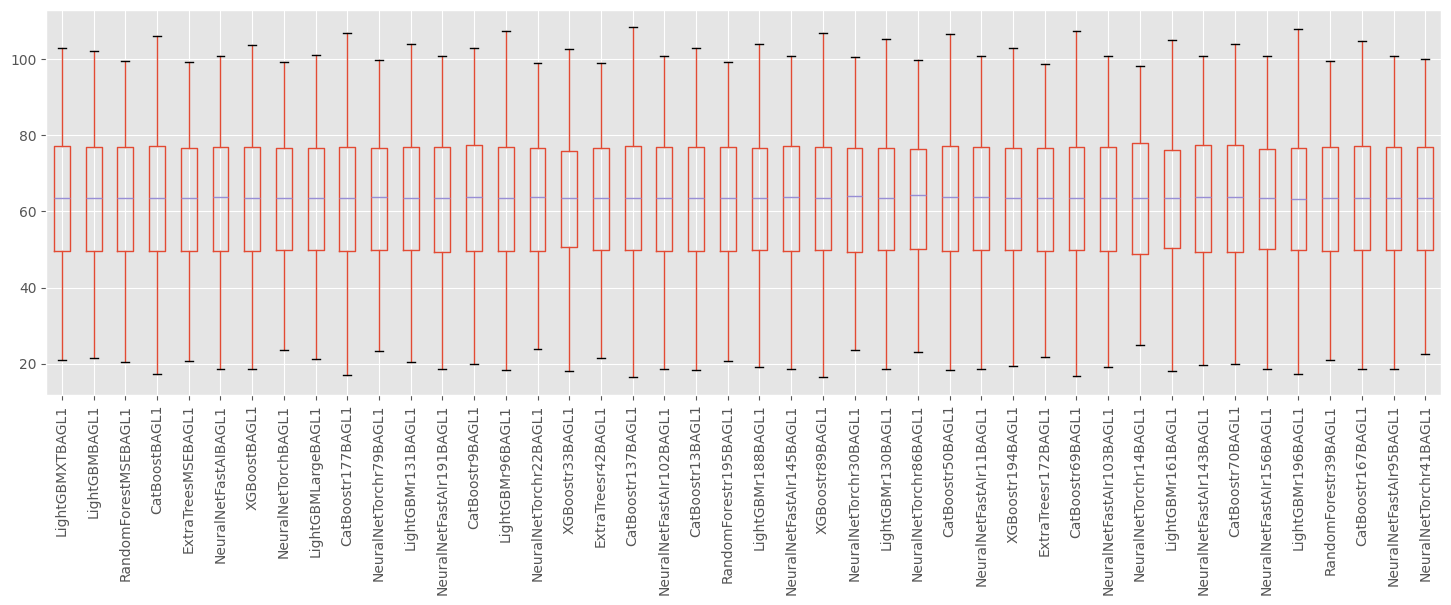

In [14]:
%%time

plt.figure(figsize=(18, 5))
ext_train.boxplot()
# sns.boxplot(ext_train)
plt.tick_params(axis='x', rotation=90)

In [15]:
## -- Merge datasets --
top_cols = ext_train.columns.tolist()

train = pd.concat([train, ext_train], axis=1)
test = pd.concat([test, ext_test], axis=1)

train.head(3)

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,LightGBMXTBAGL1,LightGBMBAGL1,RandomForestMSEBAGL1,CatBoostBAGL1,ExtraTreesMSEBAGL1,NeuralNetFastAIBAGL1,XGBoostBAGL1,NeuralNetTorchBAGL1,LightGBMLargeBAGL1,CatBoostr177BAGL1,NeuralNetTorchr79BAGL1,LightGBMr131BAGL1,NeuralNetFastAIr191BAGL1,CatBoostr9BAGL1,LightGBMr96BAGL1,NeuralNetTorchr22BAGL1,XGBoostr33BAGL1,ExtraTreesr42BAGL1,CatBoostr137BAGL1,NeuralNetFastAIr102BAGL1,CatBoostr13BAGL1,RandomForestr195BAGL1,LightGBMr188BAGL1,NeuralNetFastAIr145BAGL1,XGBoostr89BAGL1,NeuralNetTorchr30BAGL1,LightGBMr130BAGL1,NeuralNetTorchr86BAGL1,CatBoostr50BAGL1,NeuralNetFastAIr11BAGL1,XGBoostr194BAGL1,ExtraTreesr172BAGL1,CatBoostr69BAGL1,NeuralNetFastAIr103BAGL1,NeuralNetTorchr14BAGL1,LightGBMr161BAGL1,NeuralNetFastAIr143BAGL1,CatBoostr70BAGL1,NeuralNetFastAIr156BAGL1,LightGBMr196BAGL1,RandomForestr39BAGL1,CatBoostr167BAGL1,NeuralNetFastAIr95BAGL1,NeuralNetTorchr41BAGL1
0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3,85.849228,87.484894,87.250336,85.963348,85.650665,84.673004,88.859543,86.942528,88.528526,86.035973,86.280724,87.229767,86.014473,87.062050,84.768204,86.008369,85.999321,85.688667,85.564217,85.365067,85.918915,86.196999,85.050369,85.806580,85.434624,86.682762,87.138199,86.820404,85.664490,85.297905,87.340195,86.773010,85.848602,85.149376,86.894615,87.987770,87.070053,86.673767,86.080109,85.251068,87.586472,86.010040,85.801155,86.368408
1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7,66.505585,64.749687,66.686668,66.063919,67.971001,67.616310,64.070618,64.759201,64.886353,65.269135,65.693108,64.905022,66.779175,66.506699,65.921875,66.036240,67.961464,66.400330,66.139572,67.330780,65.676758,65.607330,65.914307,66.680878,64.867851,66.310768,65.341125,64.532379,66.546715,66.235313,66.255295,67.559387,65.971870,66.131531,65.177902,65.300842,68.824577,65.977997,67.815788,64.579987,66.441086,65.981041,66.404190,65.458481
2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0,77.152016,77.363297,77.894333,77.617554,79.403336,77.814629,76.773376,76.272995,77.307190,78.041023,77.191383,77.707016,75.150734,77.413681,77.242363,77.857170,78.734467,78.564003,78.189629,77.362801,77.122749,79.568665,76.010338,76.828003,77.755936,77.634041,78.213394,76.494919,78.057884,77.250107,77.195374,78.045723,77.562027,76.934341,77.951088,77.458092,77.043922,78.219803,76.179695,76.456253,79.690720,77.628494,76.542625,77.902992


In [16]:
# ## -- Factorize using combined data --
# for c in CATS:
#     combine  = pd.concat([train[c], test[c], orig[c]])
#     combine  = combine.factorize()[0]
#     train[c] = combine[:len(train)]
#     test[c]  = combine[len(train):len(train)+len(test)]
#     orig[c]  = combine[-len(orig):]

# ## -- Treat age(8 unique values) as category --
# NUMS.remove('age')
# CATS.append('age')

# print('Label encoding complete!')

In [17]:
def feature_preprocess(df):
    df_temp = df.copy()

    df_temp['study_hours_squared'] = df_temp['study_hours'] ** 2
    df_temp['study_hours_cubed'] = df_temp['study_hours'] ** 3
    df_temp['class_attendance_squared'] = df_temp['class_attendance'] ** 2
    df_temp['sleep_hours_squared'] = df_temp['sleep_hours'] ** 2
    df_temp['age_squared'] = df_temp['age'] ** 2

    # df_temp['log_study_hours'] = np.log1p(df_temp['study_hours'])
    # df_temp['log_class_attendance'] = np.log1p(df_temp['class_attendance'])
    # df_temp['log_sleep_hours'] = np.log1p(df_temp['sleep_hours'])
    # df_temp['sqrt_study_hours'] = np.sqrt(df_temp['study_hours'])
    # df_temp['sqrt_class_attendance'] = np.sqrt(df_temp['class_attendance'])

    # # Interaction features
    # df_temp['study_hours_times_attendance'] = df_temp['study_hours'] * df_temp['class_attendance']
    # df_temp['study_hours_times_sleep'] = df_temp['study_hours'] * df_temp['sleep_hours']
    # df_temp['attendance_times_sleep'] = df_temp['class_attendance'] * df_temp['sleep_hours']

    # Ratio features (add small epsilon to avoid division by zero)
    eps = 1e-6
    df_temp['study_hours_over_sleep'] = df_temp['study_hours'] / (df_temp['sleep_hours'] + eps)
    df_temp['attendance_over_sleep'] = df_temp['class_attendance'] / (df_temp['sleep_hours'] + eps)

    # # Feature by: Vladimir Demidov
    # # https://www.kaggle.com/competitions/playground-series-s6e1/discussion/665915
    # LUT = {
    #     'sleep_quality': {'good': 5, 'average': 0, 'poor': -5},
    #     'facility_rating': {'high': 4, 'medium': 0, 'low': -4},
    #     'study_method': {
    #         'coaching': 10,
    #         'mixed': 5,
    #         'group study': 2,
    #         'online videos': 1,
    #         'self-study': 0
    #     }
    # }

    # df_temp['formula'] = 6.0 * df_temp['study_hours'] + 0.35 * df_temp['class_attendance'] \
    #         + 1.5 * df_temp['sleep_hours'] \
    #         + df_temp['sleep_quality'].map(LUT['sleep_quality']) \
    #         + df_temp['study_method'].map(LUT['study_method']) \
    #         + df_temp['facility_rating'].map(LUT['facility_rating'])

    # Encode categorical variables to numeric ordinal values
    ordinal_maps = {
        "internet_access": {"no":0, "yes":1},
        "gender": {"male":0, "female":1, "other":2},
        "sleep_quality": {"poor":0, "average":1, "good":2},
        "facility_rating": {"low":0, "medium":1, "high":2},
        "exam_difficulty": {"easy":0, "moderate":1, "hard":2},
        "course": {"ba":0, "b.sc":1, "diploma":2, "b.tech":3, "b.com":4, "bca":5, "bba":6},
        "study_method": {"self-study":0, "online videos":1, "group study":2, "mixed":3, "coaching":4},
    }

    for c in CATS:
        df_temp[c] = df_temp[c].map(ordinal_maps[c]).fillna(-1)

    # Interaction between encoded categoricals and key numeric features
    df_temp['study_hours_times_sleep_quality'] = df_temp['study_hours'] * df_temp['sleep_quality']
    df_temp['attendance_times_facility'] = df_temp['class_attendance'] * df_temp['facility_rating']
    df_temp['sleep_hours_times_difficulty'] = df_temp['sleep_hours'] * df_temp['exam_difficulty']
    df_temp['age_times_study_hours'] = df_temp['age'] * df_temp['study_hours']
    df_temp['age_times_attendance'] = df_temp['age'] * df_temp['class_attendance']

    # Composite feature: learning efficiency
    df_temp['efficiency'] = (df_temp['study_hours'] * df_temp['class_attendance']) / (df_temp['sleep_hours'] + 1)
    df_temp["study_efficiency"] = df_temp["study_hours"] * (df_temp["class_attendance"] / 100.0)

    # Cyclic features
    for p in [12, 14, 365//2, 365, 365*2, 365*4]: #
        df_temp[f"study_hours_sin_{p}"] = np.sin(2 * np.pi * df_temp['study_hours'] / p)
        df_temp[f"class_attendance_sin_{p}"] = np.sin(2 * np.pi * df_temp['class_attendance'] / p)

    total_features = [c for c in df_temp.columns if c != TARGET]
    print(f'Feature Engineered: {len(total_features)}')

    return df_temp

train = feature_preprocess(train)
test  = feature_preprocess(test)
orig  = feature_preprocess(orig)

train.head(3)

Feature Engineered: 81
Feature Engineered: 81
Feature Engineered: 37


,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,LightGBMXTBAGL1,LightGBMBAGL1,RandomForestMSEBAGL1,CatBoostBAGL1,ExtraTreesMSEBAGL1,NeuralNetFastAIBAGL1,XGBoostBAGL1,NeuralNetTorchBAGL1,LightGBMLargeBAGL1,CatBoostr177BAGL1,NeuralNetTorchr79BAGL1,LightGBMr131BAGL1,NeuralNetFastAIr191BAGL1,CatBoostr9BAGL1,LightGBMr96BAGL1,NeuralNetTorchr22BAGL1,XGBoostr33BAGL1,ExtraTreesr42BAGL1,CatBoostr137BAGL1,NeuralNetFastAIr102BAGL1,CatBoostr13BAGL1,RandomForestr195BAGL1,LightGBMr188BAGL1,NeuralNetFastAIr145BAGL1,XGBoostr89BAGL1,NeuralNetTorchr30BAGL1,LightGBMr130BAGL1,NeuralNetTorchr86BAGL1,CatBoostr50BAGL1,NeuralNetFastAIr11BAGL1,XGBoostr194BAGL1,ExtraTreesr172BAGL1,CatBoostr69BAGL1,NeuralNetFastAIr103BAGL1,NeuralNetTorchr14BAGL1,LightGBMr161BAGL1,NeuralNetFastAIr143BAGL1,CatBoostr70BAGL1,NeuralNetFastAIr156BAGL1,LightGBMr196BAGL1,RandomForestr39BAGL1,CatBoostr167BAGL1,NeuralNetFastAIr95BAGL1,NeuralNetTorchr41BAGL1,study_hours_squared,study_hours_cubed,class_attendance_squared,sleep_hours_squared,age_squared,study_hours_over_sleep,attendance_over_sleep,study_hours_times_sleep_quality,attendance_times_facility,sleep_hours_times_difficulty,age_times_study_hours,age_times_attendance,efficiency,study_efficiency,study_hours_sin_12,class_attendance_sin_12,study_hours_sin_14,class_attendance_sin_14,study_hours_sin_182,class_attendance_sin_182,study_hours_sin_365,class_attendance_sin_365,study_hours_sin_730,class_attendance_sin_730,study_hours_sin_1460,class_attendance_sin_1460
0,21,1,1,7.91,98.8,0,4.9,1,1,0,0,78.3,85.849228,87.484894,87.250336,85.963348,85.650665,84.673004,88.859543,86.942528,88.528526,86.035973,86.280724,87.229767,86.014473,87.062050,84.768204,86.008369,85.999321,85.688667,85.564217,85.365067,85.918915,86.196999,85.050369,85.806580,85.434624,86.682762,87.138199,86.820404,85.664490,85.297905,87.340195,86.773010,85.848602,85.149376,86.894615,87.987770,87.070053,86.673767,86.080109,85.251068,87.586472,86.010040,85.801155,86.368408,62.5681,494.913671,9761.44,24.01,441,1.614285,20.163261,7.91,0.0,0.0,166.11,2074.8,132.458983,7.81508,-0.841511,0.994522,-0.397148,0.351375,0.269696,-0.266037,0.135744,0.991566,0.068030,0.751532,0.034035,0.412495
1,18,2,2,4.95,94.8,1,4.7,0,0,1,1,46.7,66.505585,64.749687,66.686668,66.063919,67.971001,67.616310,64.070618,64.759201,64.886353,65.269135,65.693108,64.905022,66.779175,66.506699,65.921875,66.036240,67.961464,66.400330,66.139572,67.330780,65.676758,65.607330,65.914307,66.680878,64.867851,66.310768,65.341125,64.532379,66.546715,66.235313,66.255295,67.559387,65.971870,66.131531,65.177902,65.300842,68.824577,65.977997,67.815788,64.579987,66.441086,65.981041,66.404190,65.458481,24.5025,121.287375,8987.04,22.09,324,1.053191,20.170208,0.00,94.8,4.7,89.10,1706.4,82.326316,4.69260,0.522499,-0.587785,0.795625,-0.990950,0.170058,-0.130811,0.085107,0.998133,0.042592,0.728379,0.021301,0.396753
2,20,1,1,4.68,92.6,1,5.8,0,4,2,1,99.0,77.152016,77.363297,77.894333,77.617554,79.403336,77.814629,76.773376,76.272995,77.307190,78.041023,77.191383,77.707016,75.150734,77.413681,77.242363,77.857170,78.734467,78.564003,78.189629,77.362801,77.122749,79.568665,76.010338,76.828003,77.755936,77.634041,78.213394,76.494919,78.057884,77.250107,77.195374,78.045723,77.562027,76.934341,77.951088,77.458092,77.043922,78.219803,76.179695,76.456253,79.690720,77.628494,76.542625,77.902992,21.9024,102.503232,8574.76,33.64,400,0.806896,15.965514,0.00,185.2,5.8,93.60,1852.0,63.730588,4.33368,0.637424,-0.978148,0.863018,-0.657939,0.160866,-0.055209,0.080475,0.999730,0.040270,0.715275,0.020139,0.388044


In [18]:
# ## -- Create 'meta' feature --
# ## -- https://www.kaggle.com/competitions/playground-series-s6e1/discussion/665915
# def meta_feature(df):
#     formula = (
#         6.0 * df.study_hours + \
#         0.35 * df.class_attendance + \
#         1.5 * df.sleep_hours + \
#         5 * (df.sleep_quality=='good') + \
#         -5 * (df.sleep_quality=='poor') + \
#         10 * (df.study_method=='coaching') + \
#         5 * (df.study_method=='mixed') + \
#         2 * (df.study_method=='group study') + \
#         1 * (df.study_method=='online videos') + \
#         4 * (df.facility_rating=='high') + \
#         -4 * (df.facility_rating=='low')
#     )
#     return formula

# print("'formula' feature created!")
# train['formula'] = meta_feature(train)
# test['formula'] = meta_feature(test)
# orig['formula'] = meta_feature(orig)

# ## -- Set ordinal mapping --
# ordinal_maps = {
#     "internet_access": {"no":0, "yes":1},
#     "gender": {"male":0, "female":1, "other":2},
#     "sleep_quality": {"poor":0, "average":1, "good":2},
#     "facility_rating": {"low":0, "medium":1, "high":2},
#     "exam_difficulty": {"easy":0, "moderate":1, "hard":2},
#     "course": {"ba":0, "b.sc":1, "diploma":2, "b.tech":3, "b.com":4, "bca":5, "bba":6},
#     "study_method": {"self-study":0, "online videos":1, "group study":2, "mixed":3, "coaching":4},
# }

# for c in CATS:
#     train[c] = train[c].map(ordinal_maps[c]).fillna(-1)
#     test[c] = test[c].map(ordinal_maps[c]).fillna(-1)
#     orig[c] = orig[c].map(ordinal_maps[c]).fillna(-1)

# print("Ordinal label encoded")

In [19]:
## -- Duplicate all features as categories --
CATS_2 = []

for c in BASE:
    n = f"cat_{c}"
    train[n] = train[c].copy()
    test[n] = test[c].copy()
    orig[n] = orig[c].copy()
    CATS_2.append(n)

## -- Factorize using combined data --
    combine  = pd.concat([train[n], test[n], orig[n]])
    v, _ = combine.factorize()
    train[n] = v[:len(train)]
    test[n]  = v[len(train):len(train)+len(test)]
    orig[n]  = v[len(train)+len(test):]

print('CATS_2 - Label encoding complete!')

CATS_2 - Label encoding complete!


In [20]:
for k, v in dict(age=45, sleep=9.4, classy=92.6, study=6.59).items():
    print(f'{k:<6}| ---------------')
    for i in range(-2, 2):
        print(f'Round_{i:<2}: {v} = {np.round(v, i)}')

age   | ---------------
Round_-2: 45 = 0
Round_-1: 45 = 40
Round_0 : 45 = 45
Round_1 : 45 = 45
sleep | ---------------
Round_-2: 9.4 = 0.0
Round_-1: 9.4 = 10.0
Round_0 : 9.4 = 9.0
Round_1 : 9.4 = 9.4
classy| ---------------
Round_-2: 92.6 = 100.0
Round_-1: 92.6 = 90.0
Round_0 : 92.6 = 93.0
Round_1 : 92.6 = 92.6
study | ---------------
Round_-2: 6.59 = 0.0
Round_-1: 6.59 = 10.0
Round_0 : 6.59 = 7.0
Round_1 : 6.59 = 6.6


In [21]:
TOP_PREDICTORS = ['study_hours', 'class_attendance']
OTHER_PREDICTORS = [c for c in BASE if c not in TOP_PREDICTORS]

print('Feature sets defined!')

Feature sets defined!


In [22]:
# ROUND = []
# for col in tqdm(TOP_PREDICTORS+['sleep_hours', 'age']):
#     for r in [-1, 0, 1]:
#         n = f"{col}_r{r}"
#         train[n] = train[col].round(r).astype('int8')
#         test[n] = test[col].round(r).astype('int8')
#         orig[n] = test[col].round(r).astype('int8')

#         ## -- Drop constant features --
#         if train[n].nunique() < 2:
#             train.drop([n], axis=1, inplace=True)
#             test.drop([n],  axis=1, inplace=True)
#             orig.drop([n],  axis=1, inplace=True)
#         else:
#             ROUND.append(n)

# print(f'{len(ROUND)} ROUND Features created.')
# print(train[ROUND].nunique())

In [23]:
# DOUBLES = [c for c in BASE if train_df[c].dtype == 'float']
ROUND = []

for col in tqdm(TOP_PREDICTORS): #+['formula']
    for r in range(-2, 4):
        n = f"{col}_r{r}"
        train[n] = train[col].round(r).astype('int32')
        test[n]  = test[col].round(r).astype('int32')
        orig[n]  = test[col].round(r).astype('int32')

        ## -- Drop constant features --
        if train[n].nunique() < 3:
            train.drop([n], axis=1, inplace=True)
            test.drop([n],  axis=1, inplace=True)
            orig.drop([n],  axis=1, inplace=True)
        else:
            ROUND.append(n)

print(f'Total ROUNDed Features: {len(ROUND)}')
print(train[ROUND].nunique())

  0%|          | 0/2 [00:00<?, ?it/s]

Total ROUNDed Features: 9
study_hours_r0           9
study_hours_r1           8
study_hours_r2           8
study_hours_r3           8
class_attendance_r-1     7
class_attendance_r0     59
class_attendance_r1     60
class_attendance_r2     60
class_attendance_r3     60
dtype: int64


In [24]:
# ROUND_2 = []

# for col in tqdm(top_cols): #+['formula']
#     for r in range(-2, 6):
#         n = f"{col}_r{r}"
#         train[n] = train[col].round(r).astype('int32')
#         test[n]  = test[col].round(r).astype('int32')
#         # orig[n]  = test[col].round(r).astype('int32')

#         ## -- Drop constant features --
#         if train[n].nunique() < 3:
#             train.drop([n], axis=1, inplace=True)
#             test.drop([n],  axis=1, inplace=True)
#             # orig.drop([n],  axis=1, inplace=True)
#         else:
#             ROUND_2.append(n)

# print(f'Total ROUNDed Features: {len(ROUND_2)}')
# print(train[ROUND_2].nunique())

In [25]:
## -- Extract Digits --
DIGITS = []

for col in tqdm(TOP_PREDICTORS+['sleep_hours']): #, 'formula'
    for d in range(-2, 4):
        n = f'{col}_d{d}'
        train[n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
        test[n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
        orig[n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')

        ## -- Drop constant features --
        if train[n].nunique() < 2:
            train.drop([n], axis=1, inplace=True)
            test.drop([n],  axis=1, inplace=True)
            orig.drop([n],  axis=1, inplace=True)
        else:
            DIGITS.append(n)

print(f'{len(DIGITS)} Feature DIGITS extracted.')
print(train[DIGITS].nunique())

  0%|          | 0/3 [00:00<?, ?it/s]

12 Feature DIGITS extracted.
study_hours_d0           8
study_hours_d1          10
study_hours_d2          10
study_hours_d3           7
class_attendance_d-1     6
class_attendance_d0     10
class_attendance_d1     10
class_attendance_d2     10
class_attendance_d3      3
sleep_hours_d0           6
sleep_hours_d1          10
sleep_hours_d2           5
dtype: int64


In [26]:
# ## -- Extract Digits --
# DIGITS_2 = []

# for col in tqdm(top_cols): # 'formula'
#     for d in range(-6, 3):
#         n = f'{col}_d{d}'
#         train[n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
#         test[n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
#         # orig[n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')

#         ## -- Drop constant features --
#         if train[n].nunique() < 2:
#             train.drop([n], axis=1, inplace=True)
#             test.drop([n],  axis=1, inplace=True)
#             # orig.drop([n],  axis=1, inplace=True)
#         else:
#             DIGITS_2.append(n)

# print(f'{len(DIGITS_2)} Feature DIGITS extracted.')
# print(train[DIGITS_2].nunique())

In [27]:
# INTER = []

# for c1, c2 in tqdm(list(combinations(TOP_PREDICTORS, 2)), desc='1-to-1 Pairwise'):
#     n_col = f"{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col] = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col] = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# # for c1, c2, c3 in tqdm(list(combinations(TOP_PREDICTORS+TOP_PREDICTORS_2, 3)), desc='Triplewise'):
# #     n_col = f"{c1}-|-{c2}-|-{c3}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
# #     test[n_col] = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
# #     INTER.append(n_col)

# for c1, c2 in tqdm(list(product(TOP_PREDICTORS, OTHER_PREDICTORS)), desc='1-to-many Pairwise'):
#     new_col = f"{c1}-|-{c2}"
#     train[new_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[new_col] = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[new_col] = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(new_col)

# print(f"Interaction Features: {len(INTER)}")

In [28]:
## -- Merge original features as columns --
USE_ORIG_COL = False
ORIG = []

if USE_ORIG_COL:
    for col in tqdm(BASE): 
        # MEAN
        mean_col = f"OTE_{col}_mean"
        mean_map = orig.groupby(col)[TARGET].mean().reset_index(name=mean_col)
    
        train = train.merge(mean_map, on=col, how='left')
        test = test.merge(mean_map, on=col, how='left')
        ORIG.append(mean_col)
    
        # COUNT
        count_col = f"OTE_{col}_count"
        count_map = orig.groupby(col).size().reset_index(name=count_col)
    
        train = train.merge(count_map, on=col, how='left')
        test = test.merge(count_map, on=col, how='left')
        ORIG.append(count_col)
    
        # # UNIQUE
        # unique_col = f"OTE_{col}_nunique"
        # unique_map = orig.groupby(col)[TARGET].nunique().reset_index(name=unique_col)
    
        # train = train.merge(unique_map, on=col, how='left')
        # test = test.merge(unique_map, on=col, how='left')
        # ORIG.append(unique_col)
    
        # STD
        std_col = f"OTE_{col}_std"
        std_map = orig.groupby(col)[TARGET].std().reset_index(name=std_col)
    
        train = train.merge(std_map, on=col, how='left')
        test = test.merge(std_map, on=col, how='left')
        ORIG.append(std_col)
    
        # MAX
        max_col = f"OTE_{col}_max"
        max_map = orig.groupby(col)[TARGET].max().reset_index(name=max_col)
    
        train = train.merge(max_map, on=col, how='left')
        test = test.merge(max_map, on=col, how='left')
        ORIG.append(max_col)
    
        # MIN
        min_col = f"OTE_{col}_min"
        min_map = orig.groupby(col)[TARGET].min().reset_index(name=min_col)
    
        train = train.merge(min_map, on=col, how='left')
        test = test.merge(min_map, on=col, how='left')
        ORIG.append(min_col)
    
        # # MEDIAN
        # median_col = f"OTE_{col}_median"
        # median_map = orig.groupby(col)[TARGET].median().reset_index(name=median_col).astype('float32')
    
        # train = train.merge(median_map, on=col, how='left')
        # test = test.merge(median_map, on=col, how='left')
        # ORIG.append(median_col)

# for col in ORIG:
#     if train[col].nunique() < 2:
#         train.drop([col], axis=1, inplace=True)
#         test.drop([col], axis=1, inplace=True)
#         ORIG.remove(col)
#     else:
#         continue

print(len(ORIG), 'Orig Features Created!')

0 Orig Features Created!


In [29]:
## -- Import AutoGluon predictions for XGB's 'base_score' --
USE_BASE = False

if USE_BASE:
    PATH_BASE  = '/kaggle/input/ps6e1-autogluon-trainorig/AG_preds/'
    train_base = pd.read_parquet(PATH_BASE+'train_ag_student_orig.parquet')['WeightedEnsembleL2'].astype('float32')
    test_base  = pd.read_parquet(PATH_BASE+'test_ag_student_orig.parquet')['WeightedEnsembleL2'].astype('float32')
    print("- Use initial base_score: TRUE")
    display(train.head(3))

In [30]:
## -- Reduce data memory --
def reduce_memory(df):
    old_size = sys.getsizeof(df) / (1024*1024)
    for c in tqdm(df.columns, desc='Reducing memory...'):
        ## -- Downcast Integer type ---
        if df[c].dtype == np.int64: 
            if df[c].min() > np.iinfo(np.int32).min and df[c].max() < np.iinfo(np.int32).max:
                df[c] = df[c].astype(np.int32)
                # if df[c].min() > np.iinfo(np.int16).min and df[c].max() < np.iinfo(np.int16).max:
                #     df[c] = df[c].astype(np.int16)
                #     if df[c].min() > np.iinfo(np.int8).min and df[c].max() < np.iinfo(np.int8).max:
                #         df[c] = df[c].astype(np.int8)
        ## -- Downcast Float type -----
        # elif df[c].dtype == np.float64:
        #     if df[c].min() > np.finfo(np.float32).min and df[c].max() < np.finfo(np.float32).max:
        #         df[c] = df[c].astype(np.float32)
                # if df[c].min() > np.finfo(np.float16).min and df[c].max() < np.finfo(np.float16).max:
                #     df[c] = df[c].astype(np.float16)

    new_size = sys.getsizeof(df) / (1024*1024)
    print(f"Size before process: {old_size:.1f}MB")
    print(f"Size after process : {new_size:.1f}MB\n")
    
    return df

train = reduce_memory(train)
test = reduce_memory(test)
orig = reduce_memory(orig)

gc.collect()

print(f"Data memory reduced!")

Reducing memory...:   0%|          | 0/114 [00:00<?, ?it/s]

Size before process: 391.7MB
Size after process : 343.7MB



Reducing memory...:   0%|          | 0/113 [00:00<?, ?it/s]

Size before process: 165.8MB
Size after process : 145.2MB



Reducing memory...:   0%|          | 0/70 [00:00<?, ?it/s]

Size before process: 9.1MB
Size after process : 7.6MB

Data memory reduced!


In [31]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train.head(3)

Total Features: 113


,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,LightGBMXTBAGL1,LightGBMBAGL1,RandomForestMSEBAGL1,CatBoostBAGL1,ExtraTreesMSEBAGL1,NeuralNetFastAIBAGL1,XGBoostBAGL1,NeuralNetTorchBAGL1,LightGBMLargeBAGL1,CatBoostr177BAGL1,NeuralNetTorchr79BAGL1,LightGBMr131BAGL1,NeuralNetFastAIr191BAGL1,CatBoostr9BAGL1,LightGBMr96BAGL1,NeuralNetTorchr22BAGL1,XGBoostr33BAGL1,ExtraTreesr42BAGL1,CatBoostr137BAGL1,NeuralNetFastAIr102BAGL1,CatBoostr13BAGL1,RandomForestr195BAGL1,LightGBMr188BAGL1,NeuralNetFastAIr145BAGL1,XGBoostr89BAGL1,NeuralNetTorchr30BAGL1,LightGBMr130BAGL1,NeuralNetTorchr86BAGL1,CatBoostr50BAGL1,NeuralNetFastAIr11BAGL1,XGBoostr194BAGL1,ExtraTreesr172BAGL1,CatBoostr69BAGL1,NeuralNetFastAIr103BAGL1,NeuralNetTorchr14BAGL1,LightGBMr161BAGL1,NeuralNetFastAIr143BAGL1,CatBoostr70BAGL1,NeuralNetFastAIr156BAGL1,LightGBMr196BAGL1,RandomForestr39BAGL1,CatBoostr167BAGL1,NeuralNetFastAIr95BAGL1,NeuralNetTorchr41BAGL1,study_hours_squared,study_hours_cubed,class_attendance_squared,sleep_hours_squared,age_squared,study_hours_over_sleep,attendance_over_sleep,study_hours_times_sleep_quality,attendance_times_facility,sleep_hours_times_difficulty,age_times_study_hours,age_times_attendance,efficiency,study_efficiency,study_hours_sin_12,class_attendance_sin_12,study_hours_sin_14,class_attendance_sin_14,study_hours_sin_182,class_attendance_sin_182,study_hours_sin_365,class_attendance_sin_365,study_hours_sin_730,class_attendance_sin_730,study_hours_sin_1460,class_attendance_sin_1460,cat_age,cat_study_hours,cat_class_attendance,cat_sleep_hours,cat_gender,cat_course,cat_internet_access,cat_sleep_quality,cat_study_method,cat_facility_rating,cat_exam_difficulty,study_hours_r0,study_hours_r1,study_hours_r2,study_hours_r3,class_attendance_r-1,class_attendance_r0,class_attendance_r1,class_attendance_r2,class_attendance_r3,study_hours_d0,study_hours_d1,study_hours_d2,study_hours_d3,class_attendance_d-1,class_attendance_d0,class_attendance_d1,class_attendance_d2,class_attendance_d3,sleep_hours_d0,sleep_hours_d1,sleep_hours_d2
0,21,1,1,7.91,98.8,0,4.9,1,1,0,0,78.3,85.849228,87.484894,87.250336,85.963348,85.650665,84.673004,88.859543,86.942528,88.528526,86.035973,86.280724,87.229767,86.014473,87.062050,84.768204,86.008369,85.999321,85.688667,85.564217,85.365067,85.918915,86.196999,85.050369,85.806580,85.434624,86.682762,87.138199,86.820404,85.664490,85.297905,87.340195,86.773010,85.848602,85.149376,86.894615,87.987770,87.070053,86.673767,86.080109,85.251068,87.586472,86.010040,85.801155,86.368408,62.5681,494.913671,9761.44,24.01,441,1.614285,20.163261,7.91,0.0,0.0,166.11,2074.8,132.458983,7.81508,-0.841511,0.994522,-0.397148,0.351375,0.269696,-0.266037,0.135744,0.991566,0.068030,0.751532,0.034035,0.412495,0,0,0,0,0,0,0,0,0,0,0,8,7,7,7,100,99,98,98,98,7,9,1,0,9,8,8,0,0,4,9,0
1,18,2,2,4.95,94.8,1,4.7,0,0,1,1,46.7,66.505585,64.749687,66.686668,66.063919,67.971001,67.616310,64.070618,64.759201,64.886353,65.269135,65.693108,64.905022,66.779175,66.506699,65.921875,66.036240,67.961464,66.400330,66.139572,67.330780,65.676758,65.607330,65.914307,66.680878,64.867851,66.310768,65.341125,64.532379,66.546715,66.235313,66.255295,67.559387,65.971870,66.131531,65.177902,65.300842,68.824577,65.977997,67.815788,64.579987,66.441086,65.981041,66.404190,65.458481,24.5025,121.287375,8987.04,22.09,324,1.053191,20.170208,0.00,94.8,4.7,89.10,1706.4,82.326316,4.69260,0.522499,-0.587785,0.795625,-0.990950,0.170058,-0.130811,0.085107,0.998133,0.042592,0.728379,0.021301,0.396753,1,1,1,1,1,1,1,1,1,1,1,5,5,4,4,90,95,94,94,94,4,9,5,0,9,4,8,0,0,4,7,0
2,20,1,1,4.68,92.6,1,5.8,0,4,2,1,99.0,77.152016,77.363297,77.894333,77.617554,79.403336,77.814629,76.773376,76.272995,77.307190,78.041023,77.191383,77.707016,75.150734,77.413681,77.242363,77.857170,78.734467,78.564003,78.189629,77.362801,77.122749,79.568665,76.010338,76.828003,77.755936,77.634041,78.213394,76.494919,78.057884,77.250107,77.195374,78.045

In [32]:
from sklearn.base import BaseEstimator, TransformerMixin

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique', 
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the 
        global mean. If 'auto', an empirical Bayes estimate is used.
        
    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping
        
        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
        
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)
        
        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]
            
            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'
                    
                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)
                    
                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()
                        
                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups
                        
                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)
                    
                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]
            
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed

# ML TRAINING

In [33]:
## -- DEFINE TRAINING PARAMETERS --
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))
    
## -- Split data --
X = train[FEATURES]
y = train[TARGET].values

kf = KFold(n_splits=8, shuffle=True, random_state=SEED)

oof_preds  = np.zeros(len(train))
test_preds = np.zeros(len(test))
fold_scores = []

TE_COLS = [c for c in BASE if train[c].nunique() > 2]

## -- Initiate Training --
tik = time()
for i, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"\n{'#'*5} Fold {i+1}/{kf.n_splits} | ", end='')

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    X_test = test[FEATURES].copy()

    # ## -- Concatenate original data if not base_score --
    # if not USE_ORIG_COL and not USE_BASE:
    #     X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
    #     y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

    # -- TE Opt1. -> Using CUSTOM 
    TE = TargetEncoder(ROUND, cv=5, smooth=0.05, aggs=['mean'], drop_original=True)
    X_train = TE.fit_transform(X_train, pd.Series(y_train))
    X_val   = TE.transform(X_val)
    X_test  = TE.transform(X_test)

    # ## -- TE Opt2. -- Using RAPIDS 
    # for c in INTER:
    #     TE = cuTE(n_folds=4, smooth=0, stat='mean', split_method='random', seed=SEED)
    #     # n = f"TE_{c}"
    #     X_train[c] = TE.fit_transform(X_train[c], y_train)
    #     X_val[c]   = TE.transform(X_val[c])
    #     X_test[c]  = TE.transform(X_test[c])

    combined = pd.concat([X_train, X_val, X_test])
    all_cats = CATS_2 + DIGITS
    for c in all_cats:
        combined[c] = combined[c].astype('category')
    X_train = combined.iloc[:len(X_train)]
    X_val   = combined.iloc[len(X_train):len(X_train)+len(X_val)]
    X_test  = combined.iloc[len(X_train)+len(X_val):]

    suffix = 'gbdt_ext_005'
    params = {
        # ---------------------------------
        # 'boosting': 'dart',
        # ---------------------------------
        # 'data_sample_strategy': 'goss',
        # 'top_rate': 0.6,
        # 'other_rate': 0.2,
        # ---------------------------------
        'objective': 'regression',
        'eval_metric': "rmse",
        'learning_rate': 0.005,
        'max_leaves': 127,
        'subsample': 0.8,
        'colsample_bytree': 0.15, # orig->0.35, ext1->0.15, ext2->0.3
        # 'reg_lambda': 0.005,
        # 'reg_alpha': 1.0,
        'random_state': SEED,
        'verbosity': -1,
        'n_jobs': os.cpu_count(),
        # 'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    }

    if USE_BASE:
        dtrain = lgb.Dataset(
            X_train,
            y_train,
            init_score=train_base.values[train_idx],
            categorical_feature=all_cats,
        )
        dval = lgb.Dataset(
            X_val, y_val,
            reference=dtrain,
            init_score=train_base.values[val_idx],
            categorical_feature=all_cats,
        )
        dtest = lgb.Dataset(
            X_test,
            init_score=test_base.values,
            categorical_feature=all_cats,
        )
    else:
        dtrain = lgb.Dataset(X_train, y_train, categorical_feature=all_cats)
        dval   = lgb.Dataset(X_val, y_val, reference=dtrain, categorical_feature=all_cats)
        dtest  = lgb.Dataset(X_test, categorical_feature=all_cats)

    print(f"Training data shape: {X_train.shape}")

    eval_result = {}
    all_eval_results = []
    model = lgb.train( 
        params,
        dtrain,
        num_boost_round = 10_000,
        valid_sets = [dtrain, dval],
        valid_names = ['train', 'valid'],
        callbacks=[lgb.early_stopping(200), lgb.log_evaluation(200), lgb.record_evaluation(eval_result)],
    )
    all_eval_results.append(eval_result)

    y_pred = model.predict(X_val)
    oof_preds[val_idx] = y_pred
    score = rmse(y_val, y_pred)
    fold_scores.append(score)

    test_preds += model.predict(X_test) / kf.n_splits

    print(f"{'#'*5} Fold {i+1} RMSE: {score:.5f}")

## -- After all folds --
overall_score = np.round(rmse(y, oof_preds), 5)
print(f"|{'-'*50}")
print(f"| OOF RMSE: {overall_score}")
print(f"| AVG RMSE: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}{RESET}")
print(f"|{'-'*50}\n")

tok = time() 
tiktok = (tok-tik) / 60
print(f"Time: {tiktok:.2f} mins")


##### Fold 1/8 | Training data shape: (551250, 113)
Training until validation scores don't improve for 200 rounds
[200]	train's l2: 114.62	valid's l2: 114.122
[400]	train's l2: 80.4356	valid's l2: 80.9305
[600]	train's l2: 74.633	valid's l2: 75.7885
[800]	train's l2: 73.1336	valid's l2: 74.7467
[1000]	train's l2: 72.4096	valid's l2: 74.3816
[1200]	train's l2: 71.8569	valid's l2: 74.1856
[1400]	train's l2: 71.3839	valid's l2: 74.0421
[1600]	train's l2: 70.9535	valid's l2: 73.9329
[1800]	train's l2: 70.5364	valid's l2: 73.8615
[2000]	train's l2: 70.1763	valid's l2: 73.8035
[2200]	train's l2: 69.8617	valid's l2: 73.7703
[2400]	train's l2: 69.5205	valid's l2: 73.7364
[2600]	train's l2: 69.199	valid's l2: 73.7155
[2800]	train's l2: 68.9167	valid's l2: 73.7005
[3000]	train's l2: 68.631	valid's l2: 73.6856
[3200]	train's l2: 68.3714	valid's l2: 73.6747
[3400]	train's l2: 68.1184	valid's l2: 73.668
[3600]	train's l2: 67.8753	valid's l2: 73.6616
[3800]	train's l2: 67.6164	valid's l2: 73.6559
[

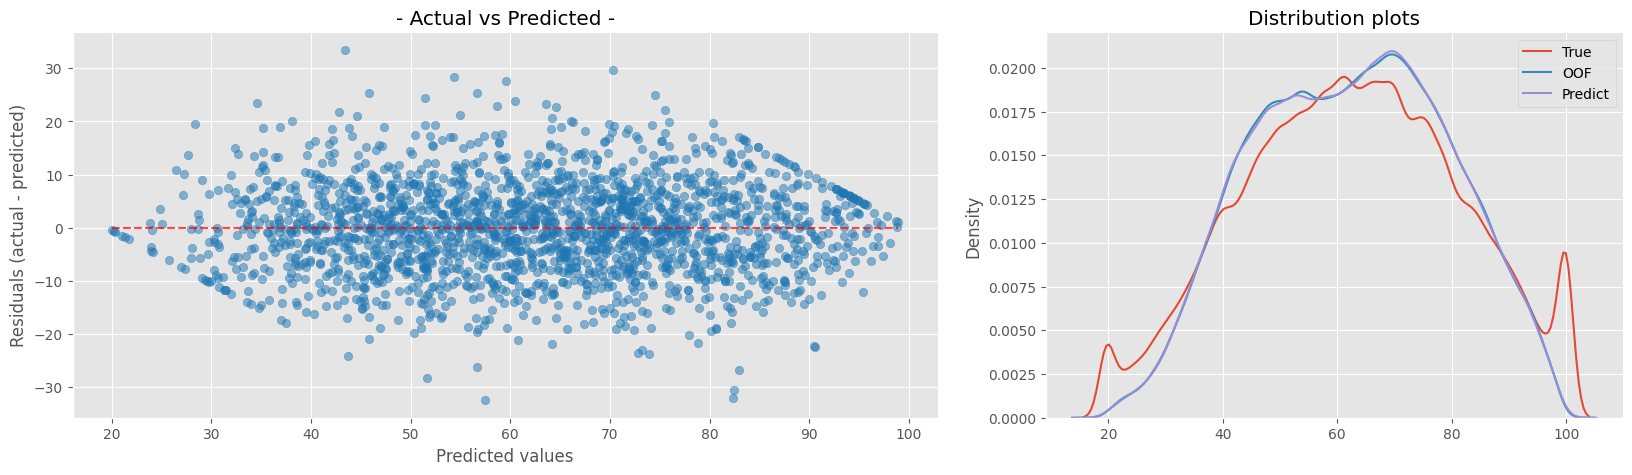

In [34]:
## -- plot_error --
_, axs = plt.subplots(1, 2, figsize=(20, 5), gridspec_kw={'width_ratios':[0.6, 0.4], 'wspace':0.15})
display = PredictionErrorDisplay.from_predictions(
    pd.Series(y), oof_preds, ax=axs[0], subsample=2000, # kind='actual_vs_predicted',
    scatter_kwargs={'alpha': 0.5}, line_kwargs={'color': 'r'},
)
axs[0].set_title(f"- Actual vs Predicted -")

LABELS = ['True', 'OOF', 'Predict']
sns.kdeplot(y, ax=axs[1], label=LABELS[0])
sns.kdeplot(oof_preds, ax=axs[1], label=LABELS[1])
sns.kdeplot(test_preds, ax=axs[1], label=LABELS[2])
axs[1].set_title(f"Distribution plots")

for ax in axs:
    # ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.legend()
plt.tight_layout()
plt.show()

In [35]:
float(overall_score)
# 5 folds + stop 200 + lr 0.1: 
# formula + orig:: gbdt-> 8.63638 || goss-> 8:63581
# external1 only:: gbdt-> 8.63287 || goss-> 8.63040
# external2 only:: gbdt-> 8.64025 || goss-> 8:64020
 
# 0.008 > 8.61537

8.61305

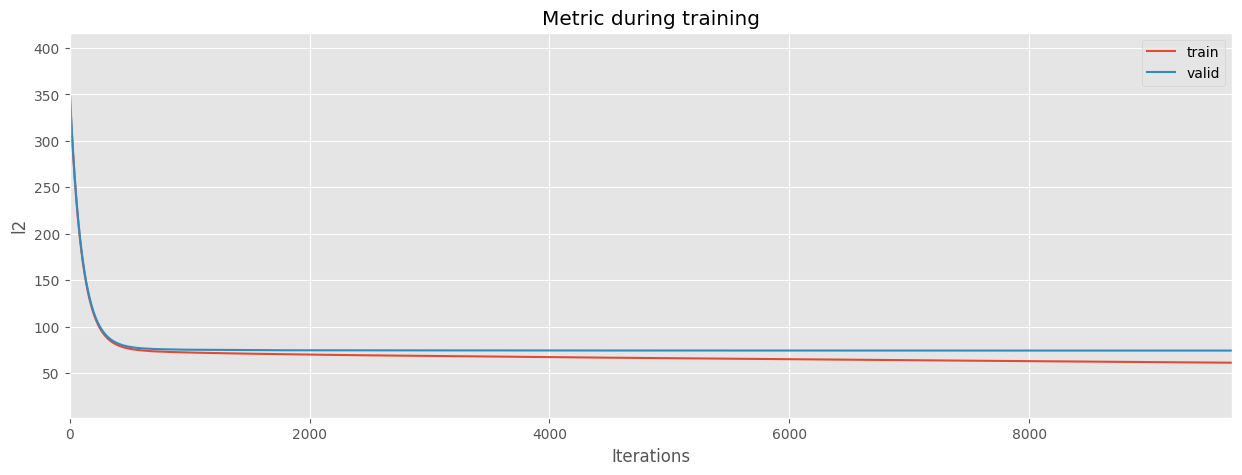

In [36]:
lgb.plot_metric(all_eval_results[0], figsize=(15, 5))
plt.show()

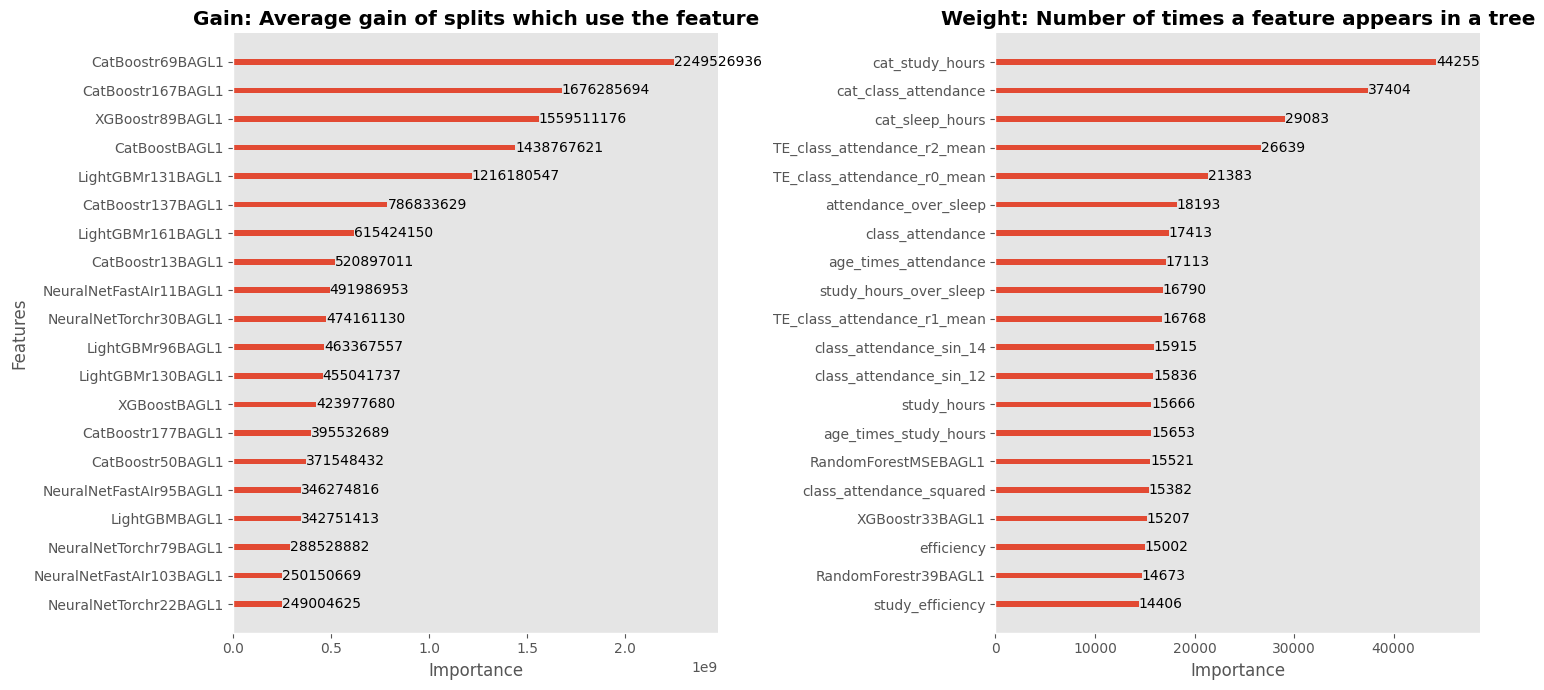

In [37]:
## -- plot_shap --
MAX = 20
_, axs = plt.subplots(1, 2, figsize=(15, 7))
lgb.plot_importance(
    model,
    importance_type='gain',
    max_num_features=MAX,
    precision=0, grid=False, ax=axs[0],
    # title="Gain: Total gains of splits which use the feature."
)
axs[0].set_title('Gain: Average gain of splits which use the feature', fontweight='semibold')

lgb.plot_importance(
    model,
    importance_type='split',
    max_num_features=MAX,
    precision=0, grid=False, ax=axs[1],
    # title="Split: Number of times the feature is used in a model."
)
axs[1].set_title('Weight: Number of times a feature appears in a tree', fontweight='semibold')
axs[1].set_ylabel('')
                 
for ax in axs:
    ax.set_xlabel('Importance')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
plt.tight_layout()
plt.show()

In [38]:
n = f"lgb_{suffix}_" + f"{overall_score}".split('.')[1]
oof_final  = pd.DataFrame(oof_preds, columns=[n])
test_final = pd.DataFrame(test_preds, columns=[n])

pd.concat([oof_final, test_final], axis=1).head()

,lgb_gbdt_ext_005_61305,lgb_gbdt_ext_005_61305
0,86.907937,69.191563
1,62.820779,68.449944
2,74.637728,89.532189
3,47.456063,55.768839
4,96.643380,46.694425


## SUBMISSION

In [39]:
## -- Save OOF & PREDICTIONS --
oof_final.to_parquet(f"oof_{n}.parquet", index=False)
test_final.to_parquet(f"pred_{n}.parquet", index=False)

## -- Submission file --
submit[TARGET] = np.clip(test_final.values, min(y), max(y))
submit.to_csv(f"submit_{n}.csv", index=False)
submit.head()

,id,exam_score
0,630000,69.191563
1,630001,68.449944
2,630002,89.532189
3,630003,55.768839
4,630004,46.694425
